In [58]:
"""
Carbon Footprint Predictor — Full Training Pipeline
=====================================================
Dataset: Kaggle "Carbon Footprint Calculator" dataset
        (filename: Carbon Emission.csv)

Sections (Steps Involved): Setup → Load Data → EDA → Preprocessing → Model Training → XGBoost Tuning → SHAP → Feature Removal → Retrain → Save Artifacts
"""

'\nCarbon Footprint Predictor — Full Training Pipeline\n=====================================================\nDataset: Kaggle "Carbon Footprint Calculator" dataset\n        (filename: Carbon Emission.csv)\n\nSections (Steps Involved): Setup → Load Data → EDA → Preprocessing → Model Training → XGBoost Tuning → SHAP → Feature Removal → Retrain → Save Artifacts\n'

1. Setup

In [59]:
%pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn plotly joblib scipy -q
print('✅ All libraries installed')

Note: you may need to restart the kernel to use updated packages.
✅ All libraries installed



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2. Load & Inspect Data

In [60]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Carbon Emission.csv')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Shape: 10000 rows x 20 columns


,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


In [61]:
# USD to INR conversion rate
usd_to_inr = 95

# Convert grocery bill to rupees
df["Monthly Grocery Bill"] = df["Monthly Grocery Bill"] * usd_to_inr

# Optional: round values
df["Monthly Grocery Bill"] = df["Monthly Grocery Bill"].round(2)

print(df["Monthly Grocery Bill"].head())

0    21850
1    10830
2    13110
3    14915
4    25270
Name: Monthly Grocery Bill, dtype: int64


In [62]:
info = pd.DataFrame({
    'dtype':    df.dtypes,
    'missing':  df.isnull().sum(),
    'missing%': (df.isnull().mean()*100).round(2),
    'unique':   df.nunique()
})
print(info.to_string())

                               dtype  missing  missing%  unique
Body Type                        str        0      0.00       4
Sex                              str        0      0.00       2
Diet                             str        0      0.00       4
How Often Shower                 str        0      0.00       4
Heating Energy Source            str        0      0.00       4
Transport                        str        0      0.00       3
Vehicle Type                     str     6721     67.21       5
Social Activity                  str        0      0.00       3
Monthly Grocery Bill           int64        0      0.00     250
Frequency of Traveling by Air    str        0      0.00       4
Vehicle Monthly Distance Km    int64        0      0.00    4003
Waste Bag Size                   str        0      0.00       4
Waste Bag Weekly Count         int64        0      0.00       7
How Long TV PC Daily Hour      int64        0      0.00      25
How Many New Clothes Monthly   int64    

In [63]:
print('Target: CarbonEmission')
print(df['CarbonEmission'].describe())
print(f'Skewness: {df["CarbonEmission"].skew():.2f}')

Target: CarbonEmission
count    10000.000000
mean      2269.147300
std       1017.675247
min        306.000000
25%       1538.000000
50%       2080.000000
75%       2768.000000
max       8377.000000
Name: CarbonEmission, dtype: float64
Skewness: 1.16


3. Exploratory Data Analysis (EDA)

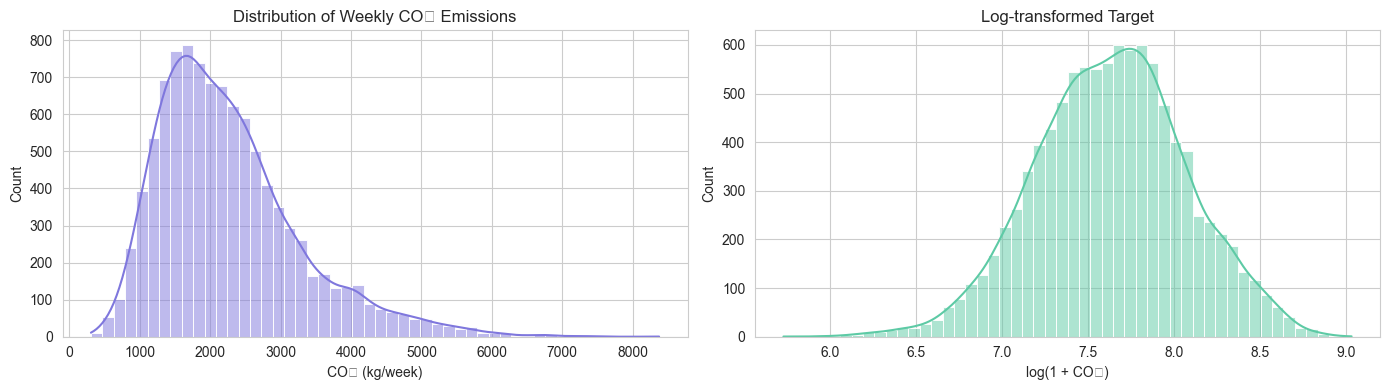

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['CarbonEmission'], bins=50, kde=True, color='#7F77DD', ax=axes[0])
axes[0].set_title('Distribution of Weekly CO₂ Emissions')
axes[0].set_xlabel('CO₂ (kg/week)')
sns.histplot(np.log1p(df['CarbonEmission']), bins=50, kde=True, color='#5DCAA5', ax=axes[1])
axes[1].set_title('Log-transformed Target')
axes[1].set_xlabel('log(1 + CO₂)')
plt.tight_layout(); plt.show()

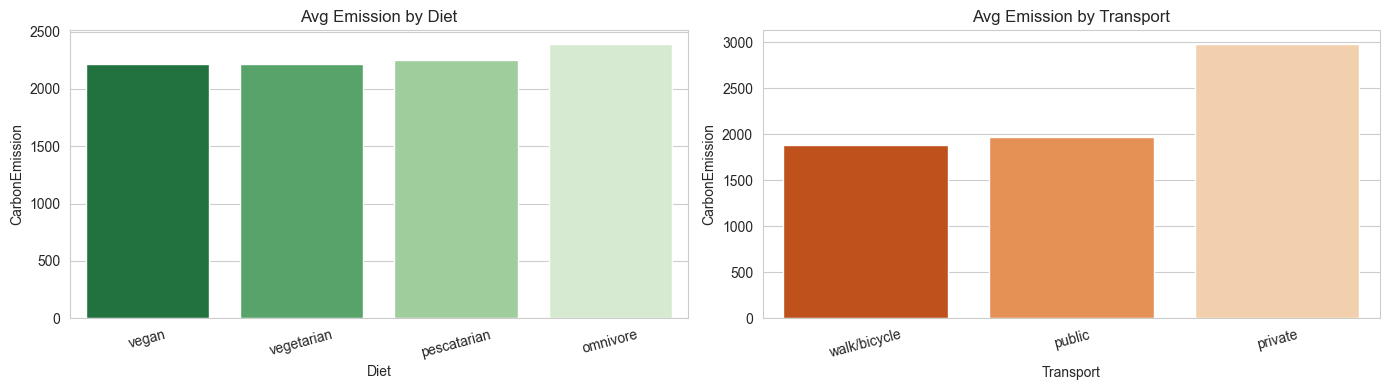

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
order1 = df.groupby('Diet')['CarbonEmission'].mean().sort_values().index
sns.barplot(data=df, x='Diet', y='CarbonEmission', order=order1, palette='Greens_r', errorbar=None, ax=axes[0])
axes[0].set_title('Avg Emission by Diet'); axes[0].tick_params(axis='x', rotation=15)
if 'Transport' in df.columns:
    order2 = df.groupby('Transport')['CarbonEmission'].mean().sort_values().index
    sns.barplot(data=df, x='Transport', y='CarbonEmission', order=order2, palette='Oranges_r', errorbar=None, ax=axes[1])
    axes[1].set_title('Avg Emission by Transport'); axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

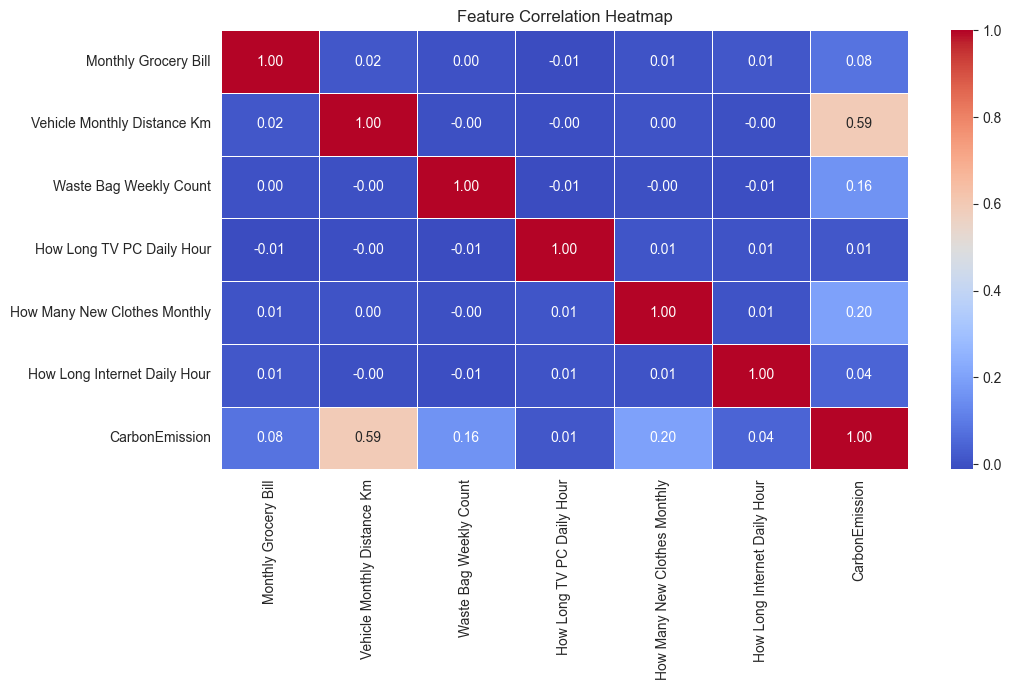

Top correlations with CarbonEmission:
CarbonEmission                  1.000000
Vehicle Monthly Distance Km     0.594171
How Many New Clothes Monthly    0.198887
Waste Bag Weekly Count          0.159193
Monthly Grocery Bill            0.081587
How Long Internet Daily Hour    0.043878
How Long TV PC Daily Hour       0.012985


In [66]:
plt.figure(figsize=(11, 7))
numeric_df = df.select_dtypes(include=[np.number])
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout(); plt.savefig('eda_correlation_heatmap.png', dpi=120); plt.show()
print('Top correlations with CarbonEmission:')
print(numeric_df.corr()['CarbonEmission'].sort_values(ascending=False).to_string())

4. Preprocessing & Feature Engineering

In [67]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

data = df.copy()
before = len(data)
data = data.drop_duplicates()
print(f'Removed {before - len(data)} duplicates')

for col in data.columns:
    if data[col].dtype == 'object' or pd.api.types.is_string_dtype(data[col]):
        data[col] = data[col].fillna(data[col].mode()[0])
    elif pd.api.types.is_numeric_dtype(data[col]):
        data[col] = data[col].fillna(data[col].median())
print('✅ Missing values filled')

Removed 0 duplicates
✅ Missing values filled


In [68]:
# ── Ordinal maps (logical order, not alphabetical) ────────────────────────────
ORDINAL_MAPS = {
    "Frequency of Traveling by Air": {"never": 0, "rarely": 1, "frequently": 2, "very frequently": 3},
    "How Often Shower":              {"less frequently": 0, "daily": 1, "more frequently": 2, "twice a day": 3},
    "Waste Bag Size":                {"small": 0, "medium": 1, "large": 2, "extra large": 3},
    "Body Type":                     {"underweight": 0, "normal": 1, "overweight": 2, "obese": 3},
    "Social Activity":               {"never": 0, "sometimes": 1, "often": 2},
    "Energy efficiency":             {"No": 0, "Sometimes": 1, "Yes": 2},
}

# Apply ordinal encoding first (removes them from label-encoder scope)
for col, mapping in ORDINAL_MAPS.items():
    if col in data.columns:
        data[col] = data[col].astype(str).str.strip().str.lower().map(
            {k.lower(): v for k, v in mapping.items()}
        ).fillna(0).astype(float)
        print(f"✅ Ordinal encoded: {col}  {mapping}")

# Nominal columns: LabelEncoder is fine for tree models (order doesn't matter)
nominal_cols = [col for col in data.columns
                if data[col].dtype == 'object' and col != 'CarbonEmission'
                and col not in ORDINAL_MAPS]
print('\nNominal (LabelEncoded):', nominal_cols)

label_encoders = {}
for col in nominal_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

print('✅ Encoding done')


✅ Ordinal encoded: Frequency of Traveling by Air  {'never': 0, 'rarely': 1, 'frequently': 2, 'very frequently': 3}
✅ Ordinal encoded: How Often Shower  {'less frequently': 0, 'daily': 1, 'more frequently': 2, 'twice a day': 3}
✅ Ordinal encoded: Waste Bag Size  {'small': 0, 'medium': 1, 'large': 2, 'extra large': 3}
✅ Ordinal encoded: Body Type  {'underweight': 0, 'normal': 1, 'overweight': 2, 'obese': 3}
✅ Ordinal encoded: Social Activity  {'never': 0, 'sometimes': 1, 'often': 2}
✅ Ordinal encoded: Energy efficiency  {'No': 0, 'Sometimes': 1, 'Yes': 2}

Nominal (LabelEncoded): []
✅ Encoding done


In [69]:
# Feature engineering
if 'Vehicle Monthly Distance Km' in data.columns:
    data['vehicle_weekly_km'] = data['Vehicle Monthly Distance Km'] / 4.33
    print('✅ vehicle_weekly_km created')

if 'Monthly Grocery Bill' in data.columns:
    data['electricity_emission_proxy'] = (data['Monthly Grocery Bill'] / 475) * 0.82 / 4.33
    print('✅ electricity_emission_proxy created')

print('Columns:', data.columns.tolist())

✅ vehicle_weekly_km created
✅ electricity_emission_proxy created
Columns: ['Body Type', 'Sex', 'Diet', 'How Often Shower', 'Heating Energy Source', 'Transport', 'Vehicle Type', 'Social Activity', 'Monthly Grocery Bill', 'Frequency of Traveling by Air', 'Vehicle Monthly Distance Km', 'Waste Bag Size', 'Waste Bag Weekly Count', 'How Long TV PC Daily Hour', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour', 'Energy efficiency', 'Recycling', 'Cooking_With', 'CarbonEmission', 'vehicle_weekly_km', 'electricity_emission_proxy']


In [70]:
skewness = data['CarbonEmission'].skew()
print(f'Skewness: {skewness:.2f}')
if skewness > 1.0:
    print('Applying log1p transform')
    data['CarbonEmission'] = np.log1p(data['CarbonEmission'])
    log_transformed = True
else:
    log_transformed = False
print(f'log_transformed = {log_transformed}')

Skewness: 1.16
Applying log1p transform
log_transformed = True


In [71]:
X = data.drop(columns=['CarbonEmission'])
y = data['CarbonEmission']
feature_names = X.columns.tolist()
print(f'Features ({len(feature_names)}): {feature_names}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Features (21): ['Body Type', 'Sex', 'Diet', 'How Often Shower', 'Heating Energy Source', 'Transport', 'Vehicle Type', 'Social Activity', 'Monthly Grocery Bill', 'Frequency of Traveling by Air', 'Vehicle Monthly Distance Km', 'Waste Bag Size', 'Waste Bag Weekly Count', 'How Long TV PC Daily Hour', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour', 'Energy efficiency', 'Recycling', 'Cooking_With', 'vehicle_weekly_km', 'electricity_emission_proxy']
Train: (8000, 21)  |  Test: (2000, 21)


In [72]:
# Fix any remaining non-numeric columns
for col in X_train.select_dtypes(exclude=[np.number]).columns:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]]).astype(str)
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    print(f'✅ Encoded: {col}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('✅ Scaling done — shape:', X_train_scaled.shape)

✅ Encoded: Sex
✅ Encoded: Diet
✅ Encoded: Heating Energy Source
✅ Encoded: Transport
✅ Encoded: Vehicle Type
✅ Encoded: Recycling
✅ Encoded: Cooking_With
✅ Scaling done — shape: (8000, 21)


5. Model Training & Comparison

In [73]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    mae   = mean_absolute_error(y_te, preds)
    r2    = r2_score(y_te, preds)
    cv    = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    return {'Model': name, 'RMSE': round(rmse,4), 'MAE': round(mae,4),
            'R²': round(r2,4), 'CV-R²': round(cv,4), '_model': model}

print('Training models... ⏳')
results = []
results.append(evaluate_model('Linear Regression',  LinearRegression(),  X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model('Ridge Regression',   Ridge(alpha=1.0),    X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model('Lasso Regression',   Lasso(alpha=0.01),   X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model('Decision Tree',       DecisionTreeRegressor(max_depth=8, random_state=42),          X_train, X_test, y_train, y_test))
results.append(evaluate_model('Random Forest',       RandomForestRegressor(n_estimators=100, random_state=42),     X_train, X_test, y_train, y_test))
results.append(evaluate_model('Gradient Boosting',  GradientBoostingRegressor(n_estimators=100, random_state=42), X_train, X_test, y_train, y_test))
results.append(evaluate_model('XGBoost',            XGBRegressor(n_estimators=100, random_state=42, verbosity=0), X_train, X_test, y_train, y_test))
print('✅ Done')

Training models... ⏳
✅ Done


In [74]:
results_df = pd.DataFrame([{k:v for k,v in r.items() if k!='_model'} for r in results])
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)

def highlight_best(s):
    is_best = s == s.max() if s.name in ['R²','CV-R²'] else s == s.min()
    return ['background-color:#de2814;font-weight:bold' if v else '' for v in is_best]

display(results_df.style.apply(highlight_best, subset=['RMSE','MAE','R²','CV-R²']))

,Model,RMSE,MAE,R²,CV-R²
0,XGBoost,0.076000,0.058800,0.969300,0.965400
1,Gradient Boosting,0.098600,0.071700,0.948300,0.937100
2,Random Forest,0.131000,0.101900,0.908700,0.902700
3,Decision Tree,0.189900,0.149000,0.808300,0.806200
4,Linear Regression,0.191300,0.140400,0.805300,0.783900
5,Ridge Regression,0.191300,0.140400,0.805300,0.783900
6,Lasso Regression,0.193600,0.142700,0.800700,0.774500


6. Hyperparameter Tuning — XGBoost

In [75]:
from sklearn.model_selection import GridSearchCV

xgb_param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1,
)
xgb_grid.fit(X_train, y_train)

print('Best params:', xgb_grid.best_params_)
print(f'Best CV-R²: {xgb_grid.best_score_:.4f}')
best_model = xgb_grid.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV-R²: 0.9798


Tuned XGBoost — RMSE: 0.0565
Tuned XGBoost — MAE : 0.0443
Tuned XGBoost — R²  : 0.9830


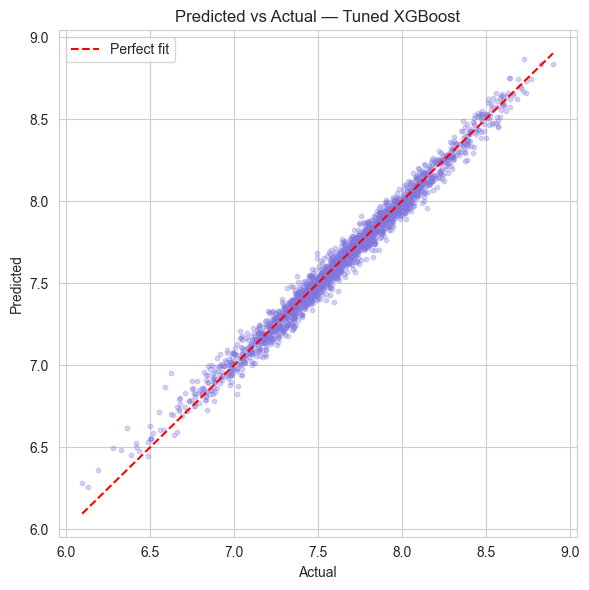

In [76]:
final_preds = best_model.predict(X_test)
print(f'Tuned XGBoost — RMSE: {np.sqrt(mean_squared_error(y_test, final_preds)):.4f}')
print(f'Tuned XGBoost — MAE : {mean_absolute_error(y_test, final_preds):.4f}')
print(f'Tuned XGBoost — R²  : {r2_score(y_test, final_preds):.4f}')

plt.figure(figsize=(6,6))
plt.scatter(y_test, final_preds, alpha=0.3, color='#7F77DD', s=10)
mn = min(y_test.min(), final_preds.min()); mx = max(y_test.max(), final_preds.max())
plt.plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Perfect fit')
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Predicted vs Actual — Tuned XGBoost')
plt.legend(); plt.tight_layout()
plt.savefig('model_predicted_vs_actual.png', dpi=120); plt.show()

7. SHAP Analysis

In [77]:
import shap

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
print(f'SHAP shape: {shap_values.shape}')
print('✅ SHAP done')

SHAP shape: (2000, 21)
✅ SHAP done


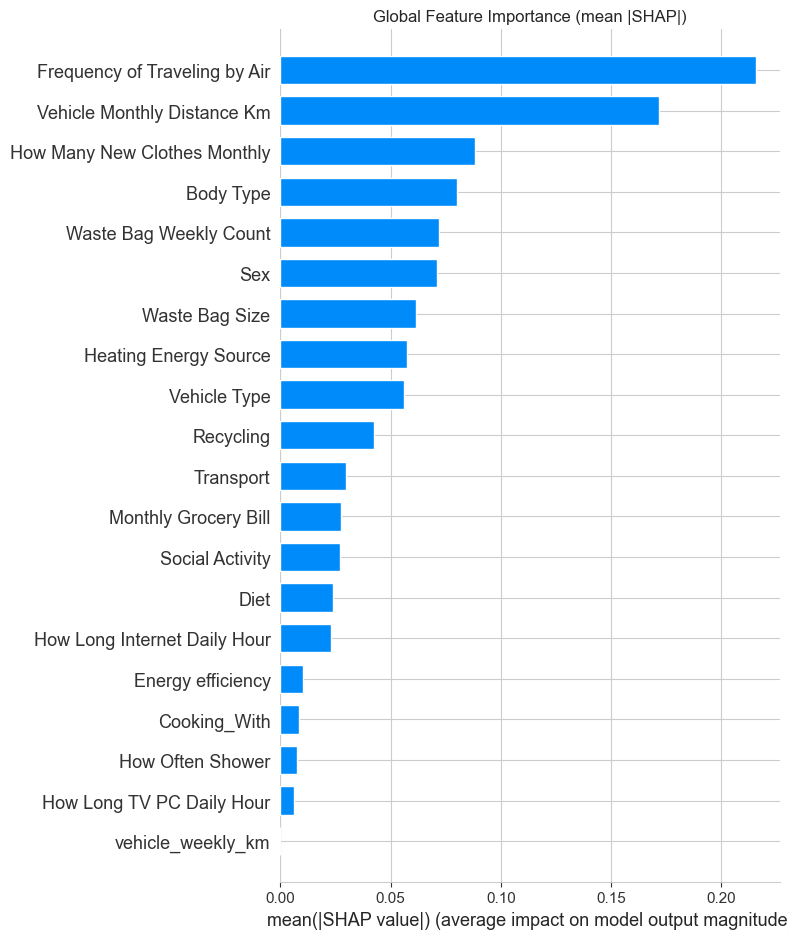

In [78]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type='bar', show=False)
plt.title('Global Feature Importance (mean |SHAP|)')
plt.tight_layout(); plt.savefig('shap_feature_importance.png', dpi=120, bbox_inches='tight'); plt.show()

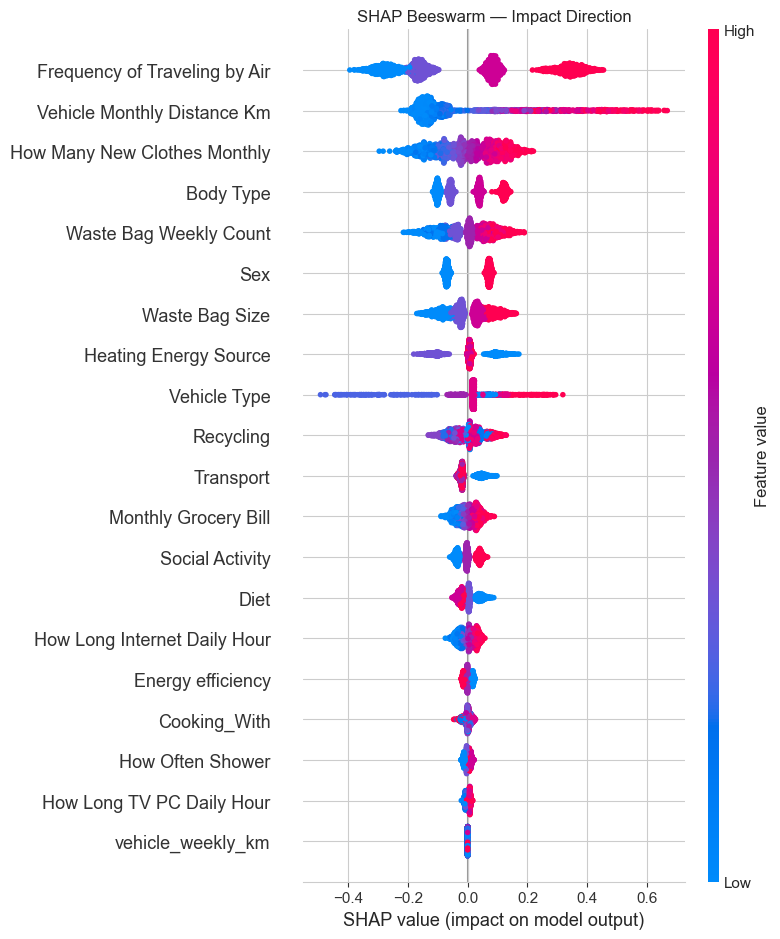

In [79]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Beeswarm — Impact Direction')
plt.tight_layout(); plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight'); plt.show()

In [80]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature':        feature_names,
    'mean_abs_shap':  mean_abs_shap.round(5)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('All features by SHAP importance:')
display(shap_df.style.bar(subset=['mean_abs_shap'], color='#C5C2F0'))

All features by SHAP importance:


,feature,mean_abs_shap
0,Frequency of Traveling by Air,0.215750
1,Vehicle Monthly Distance Km,0.171790
2,How Many New Clothes Monthly,0.088450
3,Body Type,0.079980
4,Waste Bag Weekly Count,0.071830
5,Sex,0.070840
6,Waste Bag Size,0.061400
7,Heating Energy Source,0.057480
8,Vehicle Type,0.056210
9,Recycling,0.042400


8. Remove Near-Zero SHAP Features

In [81]:
SHAP_THRESHOLD = 0.01

weak_features = shap_df[shap_df['mean_abs_shap'] < SHAP_THRESHOLD]['feature'].tolist()

print(f'\nWeak features to drop ({len(weak_features)}): {weak_features}')

X_train = X_train.drop(columns=[f for f in weak_features if f in X_train.columns])
X_test  = X_test.drop(columns=[f for f in weak_features if f in X_test.columns])
feature_names = X_train.columns.tolist()

print(f'\nRemaining features ({len(feature_names)}): {feature_names}')


Weak features to drop (5): ['Cooking_With', 'How Often Shower', 'How Long TV PC Daily Hour', 'vehicle_weekly_km', 'electricity_emission_proxy']

Remaining features (16): ['Body Type', 'Sex', 'Diet', 'Heating Energy Source', 'Transport', 'Vehicle Type', 'Social Activity', 'Monthly Grocery Bill', 'Frequency of Traveling by Air', 'Vehicle Monthly Distance Km', 'Waste Bag Size', 'Waste Bag Weekly Count', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour', 'Energy efficiency', 'Recycling']


9. Retrain XGBoost on Cleaned Feature Set

In [82]:
print('Retraining XGBoost after feature removal...')

xgb_clean = XGBRegressor(
    **xgb_grid.best_params_,
    random_state=42,
    verbosity=0
)
xgb_clean.fit(X_train, y_train)

clean_preds = xgb_clean.predict(X_test)
print(f'Final RMSE : {np.sqrt(mean_squared_error(y_test, clean_preds)):.4f}')
print(f'Final MAE  : {mean_absolute_error(y_test, clean_preds):.4f}')
print(f'Final R²   : {r2_score(y_test, clean_preds):.4f}')

best_model = xgb_clean
explainer  = shap.TreeExplainer(best_model)
print('✅ best_model and explainer updated to clean version')

Retraining XGBoost after feature removal...
Final RMSE : 0.0578
Final MAE  : 0.0448
Final R²   : 0.9823
✅ best_model and explainer updated to clean version


In [83]:
# 10-fold cross validation on final model
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_model, X_train, y_train, cv=10, scoring='r2')
print(f'10-fold CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('Low std = model generalises well')

10-fold CV R²: 0.9797 ± 0.0019
Low std = model generalises well


10. Save All Artifacts

In [84]:
import joblib

# All predictions on test set — used for peer comparison in app
all_train_preds = best_model.predict(X_test)
if log_transformed:
    all_train_preds = np.expm1(all_train_preds)

joblib.dump(best_model,          'model.pkl')
joblib.dump(scaler,              'scaler.pkl')
joblib.dump(explainer,           'explainer.pkl')
joblib.dump(label_encoders,      'label_encoders.pkl')
joblib.dump(feature_names,       'feature_names.pkl')
joblib.dump(log_transformed,     'log_transformed.pkl')
joblib.dump(weak_features,       'dropped_features.pkl')
joblib.dump(ORDINAL_MAPS,         'ordinal_maps.pkl')
joblib.dump(all_train_preds,     'all_train_preds.pkl')

print('✅ Saved all artifacts:')
print('   model.pkl            — tuned XGBoost (clean features)')
print('   scaler.pkl           — StandardScaler')
print('   explainer.pkl        — SHAP TreeExplainer')
print('   label_encoders.pkl   — LabelEncoders per categorical column')
print(f'  feature_names.pkl   — {len(feature_names)} features (after removal)')
print('   log_transformed.pkl  — True/False flag')
print(f'  dropped_features.pkl— {weak_features}')
print(f'  all_train_preds.pkl — {len(all_train_preds)} predictions for peer comparison')

✅ Saved all artifacts:
   model.pkl            — tuned XGBoost (clean features)
   scaler.pkl           — StandardScaler
   explainer.pkl        — SHAP TreeExplainer
   label_encoders.pkl   — LabelEncoders per categorical column
  feature_names.pkl   — 16 features (after removal)
   log_transformed.pkl  — True/False flag
  dropped_features.pkl— ['Cooking_With', 'How Often Shower', 'How Long TV PC Daily Hour', 'vehicle_weekly_km', 'electricity_emission_proxy']
  all_train_preds.pkl — 2000 predictions for peer comparison
